## 0. Install Required Libraries

In [ ]:
# Install any missing packages
import subprocess
packages = ['shap', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy']
for pkg in packages:
    subprocess.run(['pip', 'install', '--quiet', pkg], check=False)
print('All required packages are ready.')

All required packages are ready.


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import ttest_ind

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_validate
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import shap
shap.initjs()

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
FIGSIZE = (14, 6)

print('Libraries loaded successfully.')
print(f'Random seed set to: {RANDOM_SEED}')

Libraries loaded successfully.
Random seed set to: 42


---
## 2. Data Loading & Integration
### 2.1 Load All Three Datasets

In [ ]:
# ── Load the three CSV files ──────────────────────────────────────────────────
df_all     = pd.read_csv('/content/LIWC2015_AllReviews (3).csv')
df_decep   = pd.read_csv('/content/LIWC_Negative_Deceptive (3).csv')
df_truth   = pd.read_csv('/content/LIWC_Negative_Truthful (3).csv')

print('Dataset shapes:')
print(f'  LIWC2015_AllReviews     : {df_all.shape}')
print(f'  LIWC_Negative_Deceptive : {df_decep.shape}')
print(f'  LIWC_Negative_Truthful  : {df_truth.shape}')

# Preview AllReviews
print('\n--- AllReviews head ---')
df_all.head(3)

Dataset shapes:
  LIWC2015_AllReviews     : (1600, 96)
  LIWC_Negative_Deceptive : (400, 95)
  LIWC_Negative_Truthful  : (400, 95)

--- AllReviews head ---


,Filename,Segment,WC,Analytic,Clout,Authentic,Tone,WPS,Sixltr,Dic,...,Colon,SemiC,QMark,Exclam,Dash,Quote,Apostro,Parenth,OtherP,Class
0,d_hilton_1.txt,1,273,65.46,45.62,68.01,32.04,16.06,15.75,87.91,...,0.0,0.00,0.0,0.73,0.73,1.47,0.73,1.1,0.00,1
1,d_hilton_10.txt,1,84,90.75,85.81,68.01,47.81,16.80,14.29,84.52,...,0.0,1.19,0.0,0.00,2.38,0.00,1.19,0.0,3.57,1
2,d_hilton_11.txt,1,196,79.96,10.12,99.00,34.63,19.60,18.88,89.80,...,0.0,0.00,0.0,0.51,1.02,0.00,0.51,0.0,0.00,1


### 2.2 Integrate Negative-Sentiment Datasets with Binary Labels
> **Per §3.5.1**: Merge `LIWC_Negative_Truthful.csv` (label = 0) and `LIWC_Negative_Deceptive.csv` (label = 1) to create a balanced 798-record dataset.

In [ ]:
# Assign binary class labels: 0 = Truthful, 1 = Deceptive
df_decep = df_decep.copy()
df_truth = df_truth.copy()
df_decep['Class'] = 1
df_truth['Class'] = 0

# Merge into one balanced dataframe
df_neg = pd.concat([df_truth, df_decep], ignore_index=True)
df_neg = df_neg.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print('Merged negative-sentiment dataset:')
print(f'  Shape         : {df_neg.shape}')
print(f'  Class balance : {df_neg["Class"].value_counts().to_dict()}  (0=Truthful, 1=Deceptive)')

# AllReviews already has Class column
print(f'\nAllReviews class balance: {df_all["Class"].value_counts().to_dict()}')

Merged negative-sentiment dataset:
  Shape         : (800, 96)
  Class balance : {1: 400, 0: 400}  (0=Truthful, 1=Deceptive)

AllReviews class balance: {1: 800, 0: 800}


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Statistics

In [ ]:
# Work with the AllReviews dataset for full EDA (1600 records)
df = df_all.copy()

# Feature columns (drop identifiers)
ID_COLS   = ['Filename', 'Segment']
TARGET    = 'Class'
FEAT_COLS = [c for c in df.columns if c not in ID_COLS + [TARGET]]

print(f'Total features: {len(FEAT_COLS)}')
print(f'Total samples : {len(df)}')
print(f'Class balance : {df[TARGET].value_counts().to_dict()}')

# Descriptive statistics by class
desc = df.groupby(TARGET)[FEAT_COLS].describe().T
print('\nDescriptive statistics (first 10 features):')
df.groupby(TARGET)[FEAT_COLS[:8]].mean().T.rename(columns={0:'Truthful_Mean', 1:'Deceptive_Mean'})

Total features: 93
Total samples : 1600
Class balance : {1: 800, 0: 800}

Descriptive statistics (first 10 features):


Class,Truthful_Mean,Deceptive_Mean
WC,151.552500,147.195000
Analytic,74.532863,69.068300
Clout,57.911400,51.667812
Authentic,60.696812,64.169550
Tone,67.923075,65.500225
WPS,16.242275,16.533912
Sixltr,16.784263,17.540425
Dic,87.836012,89.688550


### 3.2 Class Distribution

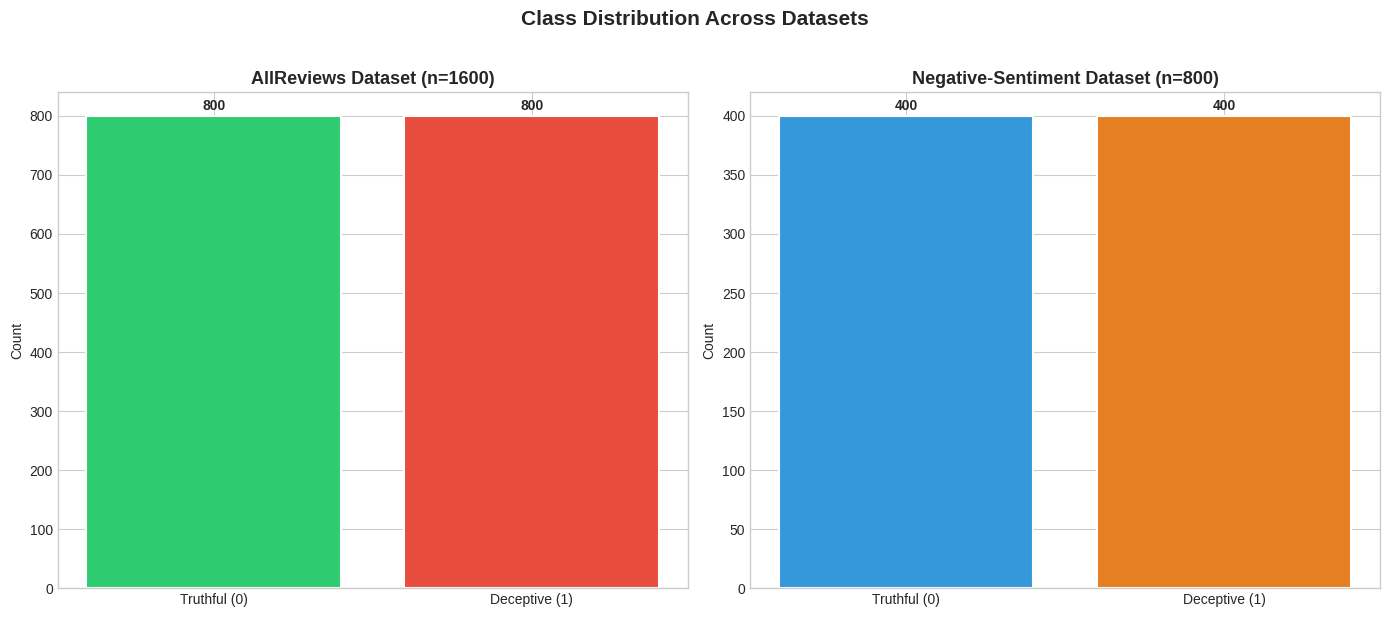

Figure saved: fig_class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# AllReviews
counts_all = df_all['Class'].value_counts()
axes[0].bar(['Truthful (0)', 'Deceptive (1)'],
            [counts_all[0], counts_all[1]],
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('AllReviews Dataset (n=1600)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts_all[0], counts_all[1]]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Negative Sentiment
counts_neg = df_neg['Class'].value_counts()
axes[1].bar(['Truthful (0)', 'Deceptive (1)'],
            [counts_neg[0], counts_neg[1]],
            color=['#3498db', '#e67e22'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Negative-Sentiment Dataset (n=800)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([counts_neg[0], counts_neg[1]]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Across Datasets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_class_distribution.png')

### 3.3 Key LIWC Feature Distributions by Class

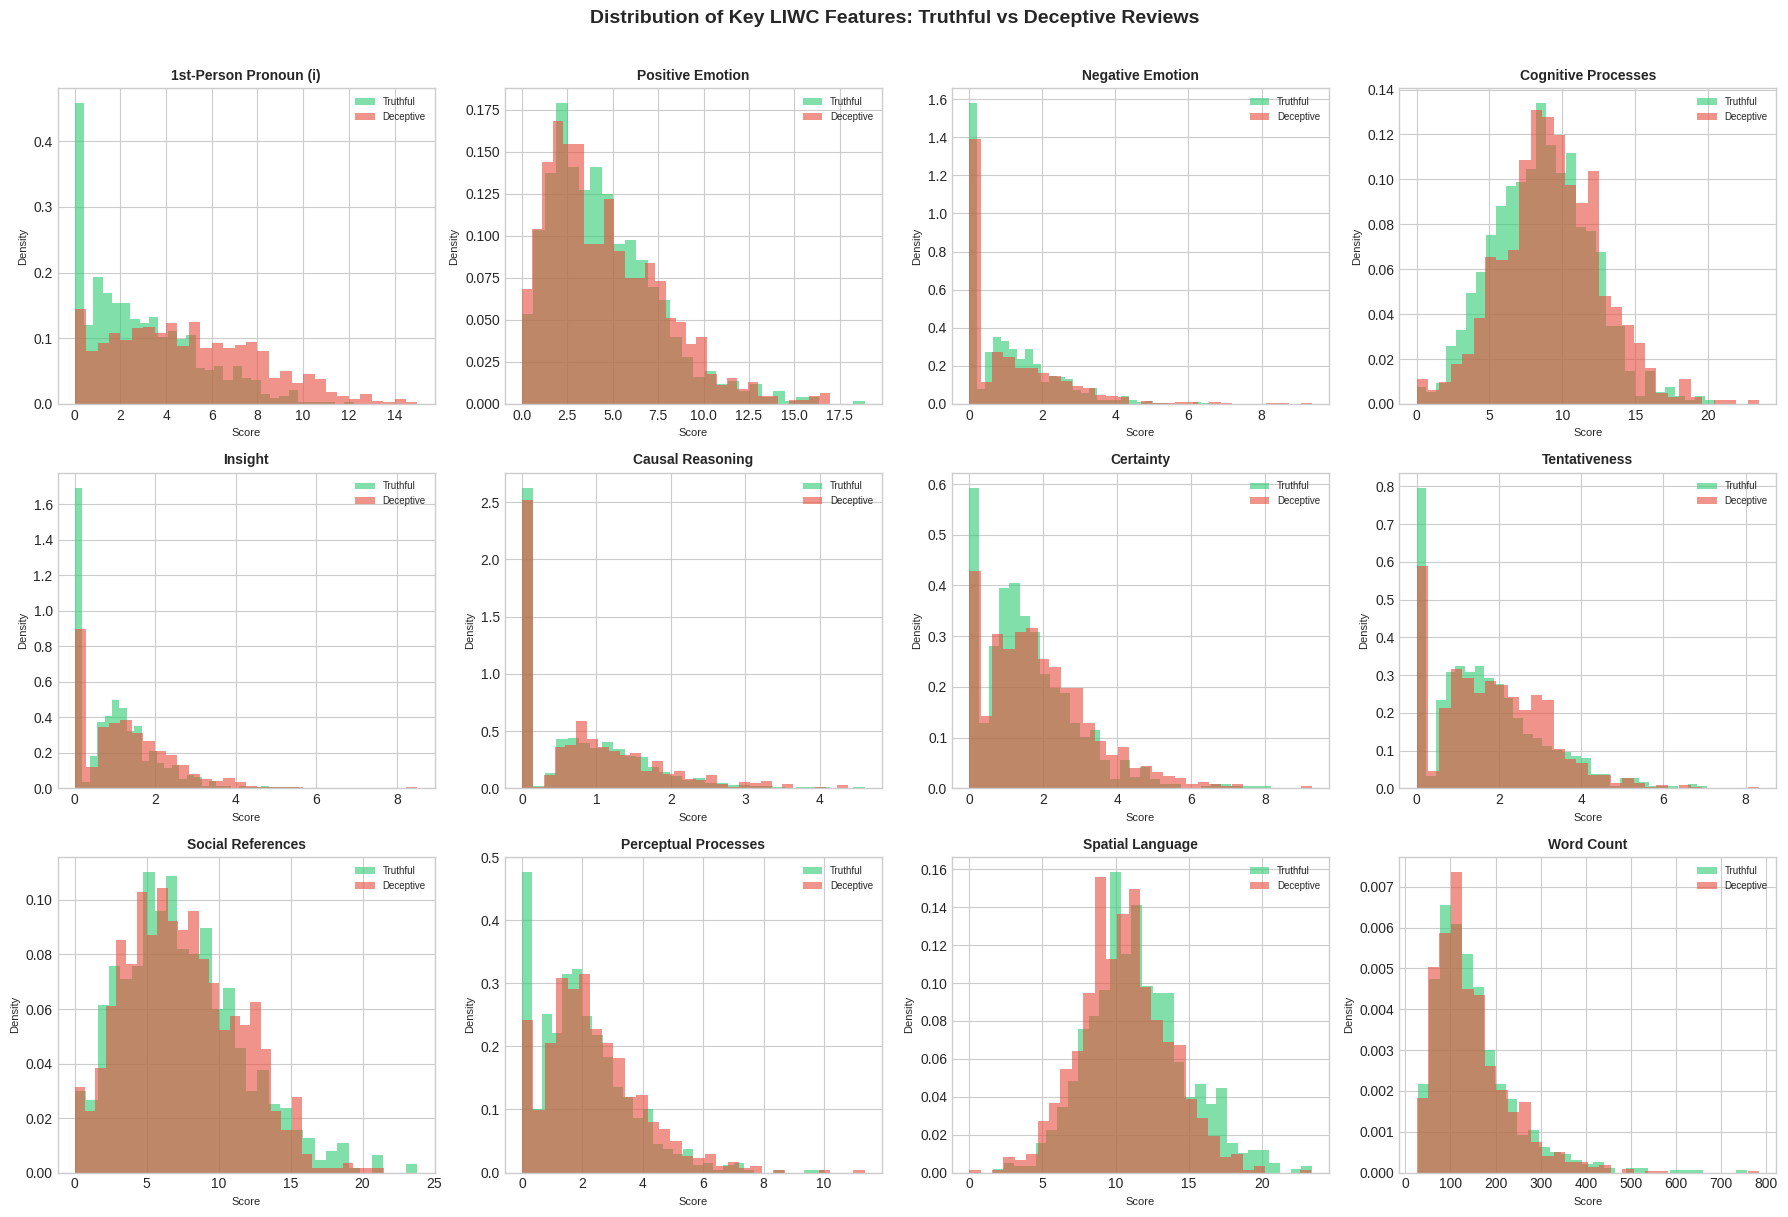

Figure saved: fig_liwc_distributions.png


In [ ]:
# Theoretically important LIWC dimensions from §3.7
KEY_FEATURES = ['i', 'posemo', 'negemo', 'cogproc', 'insight', 'cause',
                'certain', 'tentat', 'social', 'percept', 'space', 'WC']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

df_t = df[df[TARGET] == 0][KEY_FEATURES]
df_d = df[df[TARGET] == 1][KEY_FEATURES]

FEATURE_LABELS = {
    'i': '1st-Person Pronoun (i)', 'posemo': 'Positive Emotion',
    'negemo': 'Negative Emotion', 'cogproc': 'Cognitive Processes',
    'insight': 'Insight', 'cause': 'Causal Reasoning',
    'certain': 'Certainty', 'tentat': 'Tentativeness',
    'social': 'Social References', 'percept': 'Perceptual Processes',
    'space': 'Spatial Language', 'WC': 'Word Count'
}

for idx, feat in enumerate(KEY_FEATURES):
    ax = axes[idx]
    ax.hist(df_t[feat], bins=30, alpha=0.6, color='#2ecc71', label='Truthful', density=True)
    ax.hist(df_d[feat], bins=30, alpha=0.6, color='#e74c3c', label='Deceptive', density=True)
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=10, fontweight='bold')
    ax.set_xlabel('Score', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Distribution of Key LIWC Features: Truthful vs Deceptive Reviews',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_liwc_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_liwc_distributions.png')

### 3.4 Statistical Significance Testing (Independent-Samples t-Tests with Effect Size)
> **Per §3.7**: Compare mean LIWC scores between deceptive and truthful classes using t-tests and Cohen's d effect size.

In [ ]:
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / (pooled_std + 1e-10)

truthful  = df[df[TARGET] == 0][FEAT_COLS]
deceptive = df[df[TARGET] == 1][FEAT_COLS]

results = []
for feat in FEAT_COLS:
    t_stat, p_val = ttest_ind(truthful[feat].dropna(), deceptive[feat].dropna())
    d = cohens_d(deceptive[feat].dropna(), truthful[feat].dropna())
    results.append({
        'Feature'        : feat,
        'Truthful_Mean'  : truthful[feat].mean(),
        'Deceptive_Mean' : deceptive[feat].mean(),
        'Mean_Diff'      : deceptive[feat].mean() - truthful[feat].mean(),
        't_statistic'    : t_stat,
        'p_value'        : p_val,
        'Cohen_d'        : d,
        'Significant_005': p_val < 0.05
    })

ttest_df = pd.DataFrame(results).sort_values('Cohen_d', ascending=False, key=abs)
sig_df   = ttest_df[ttest_df['Significant_005'] == True]

print(f'Total features tested     : {len(ttest_df)}')
print(f'Significant (p < 0.05)    : {len(sig_df)}')
print(f'\nTop 15 by |Cohen\'s d|:')
ttest_df.head(15)[['Feature','Truthful_Mean','Deceptive_Mean','Mean_Diff','p_value','Cohen_d']].round(4)

Total features tested     : 93
Significant (p < 0.05)    : 58

Top 15 by |Cohen's d|:


,Feature,Truthful_Mean,Deceptive_Mean,Mean_Diff,p_value,Cohen_d
81,AllPunc,15.7894,12.3215,-3.4678,0.0,-0.7314
11,i,2.8940,4.9172,2.0231,0.0,0.7068
92,OtherP,0.6084,0.1239,-0.4845,0.0,-0.5940
27,number,2.0066,1.1760,-0.8306,0.0,-0.5731
10,ppron,6.7537,8.4938,1.7401,0.0,0.5469
91,Parenth,0.8139,0.2395,-0.5744,0.0,-0.5436
9,pronoun,10.5918,12.4765,1.8848,0.0,0.4958
8,function,52.5605,55.0065,2.4460,0.0,0.4948
82,Period,7.2992,5.9258,-1.3735,0.0,-0.4799
7,Dic,87.8360,89.6885,1.8525,0.0,0.4584


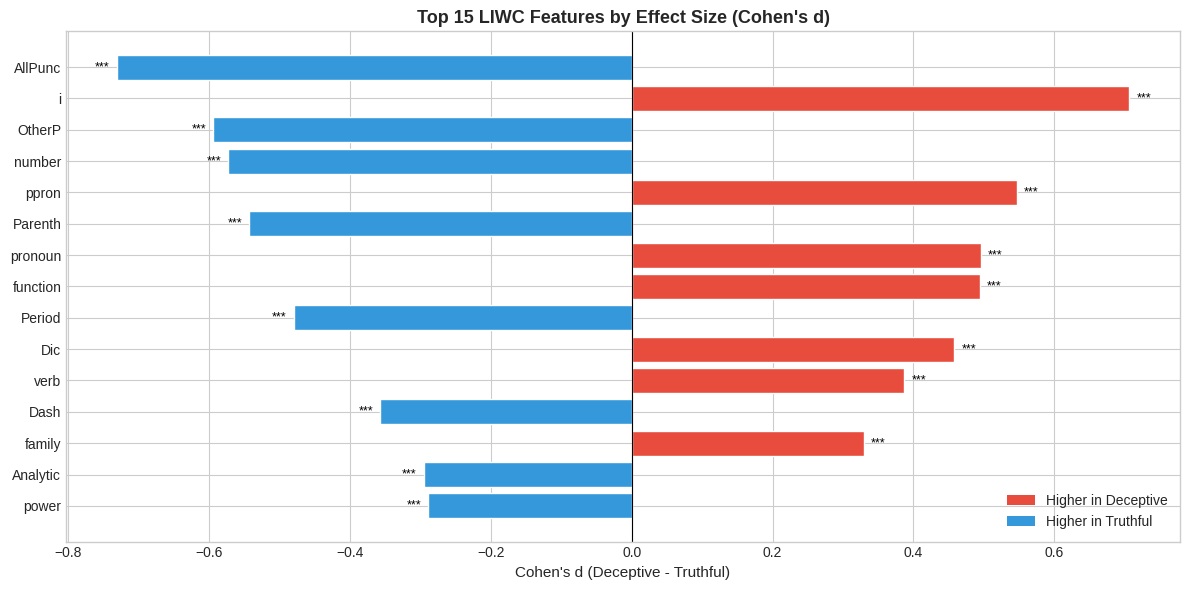

Figure saved: fig_cohens_d_top15.png


In [ ]:
# Visualise top significant features by Cohen's d
top15 = ttest_df.head(15).copy()
colors = ['#e74c3c' if d > 0 else '#3498db' for d in top15['Cohen_d']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['Feature'], top15['Cohen_d'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Cohen's d (Deceptive - Truthful)", fontsize=11)
ax.set_title('Top 15 LIWC Features by Effect Size (Cohen\'s d)', fontsize=13, fontweight='bold')

# Annotate p-values
for bar, (_, row) in zip(bars, top15.iterrows()):
    sig_label = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
    x_pos = bar.get_width() + 0.01 if bar.get_width() > 0 else bar.get_width() - 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, sig_label,
            va='center', ha='left' if bar.get_width() > 0 else 'right', fontsize=9, color='black')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Higher in Deceptive'),
                   Patch(facecolor='#3498db', label='Higher in Truthful')]
ax.legend(handles=legend_elements, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_cohens_d_top15.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_cohens_d_top15.png')

### 3.5 Correlation Heatmap of Key LIWC Features

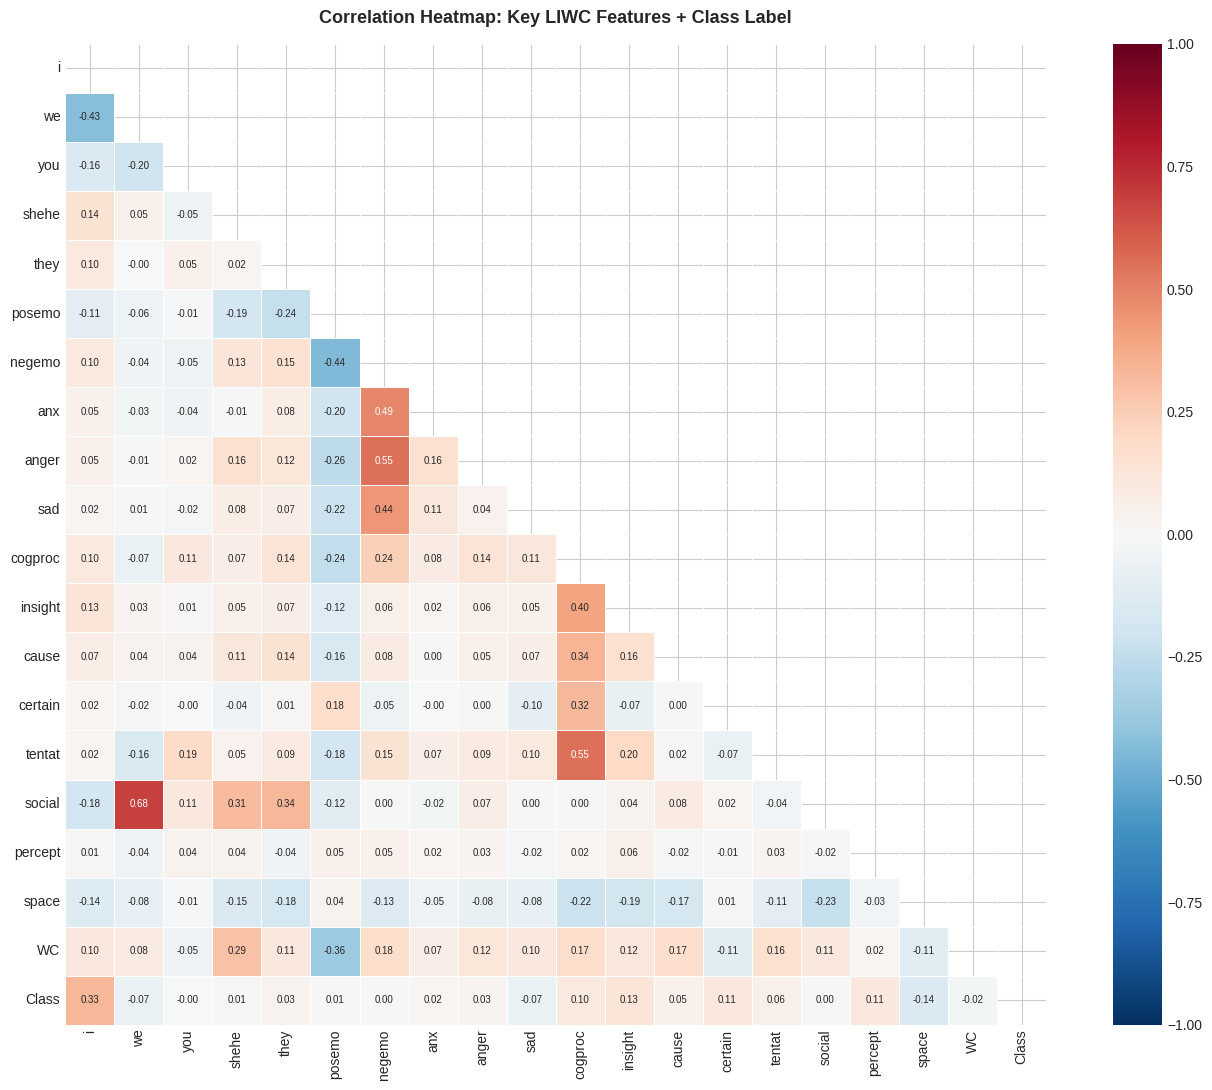

Figure saved: fig_correlation_heatmap.png


In [ ]:
# Extended set of theoretically motivated features
THEORY_FEATS = ['i', 'we', 'you', 'shehe', 'they', 'posemo', 'negemo',
                'anx', 'anger', 'sad', 'cogproc', 'insight', 'cause',
                'certain', 'tentat', 'social', 'percept', 'space', 'WC', TARGET]

corr_matrix = df[THEORY_FEATS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Heatmap: Key LIWC Features + Class Label',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_correlation_heatmap.png')

### 3.6 Box Plots: Deceptive vs Truthful (Theoretically Key Features)

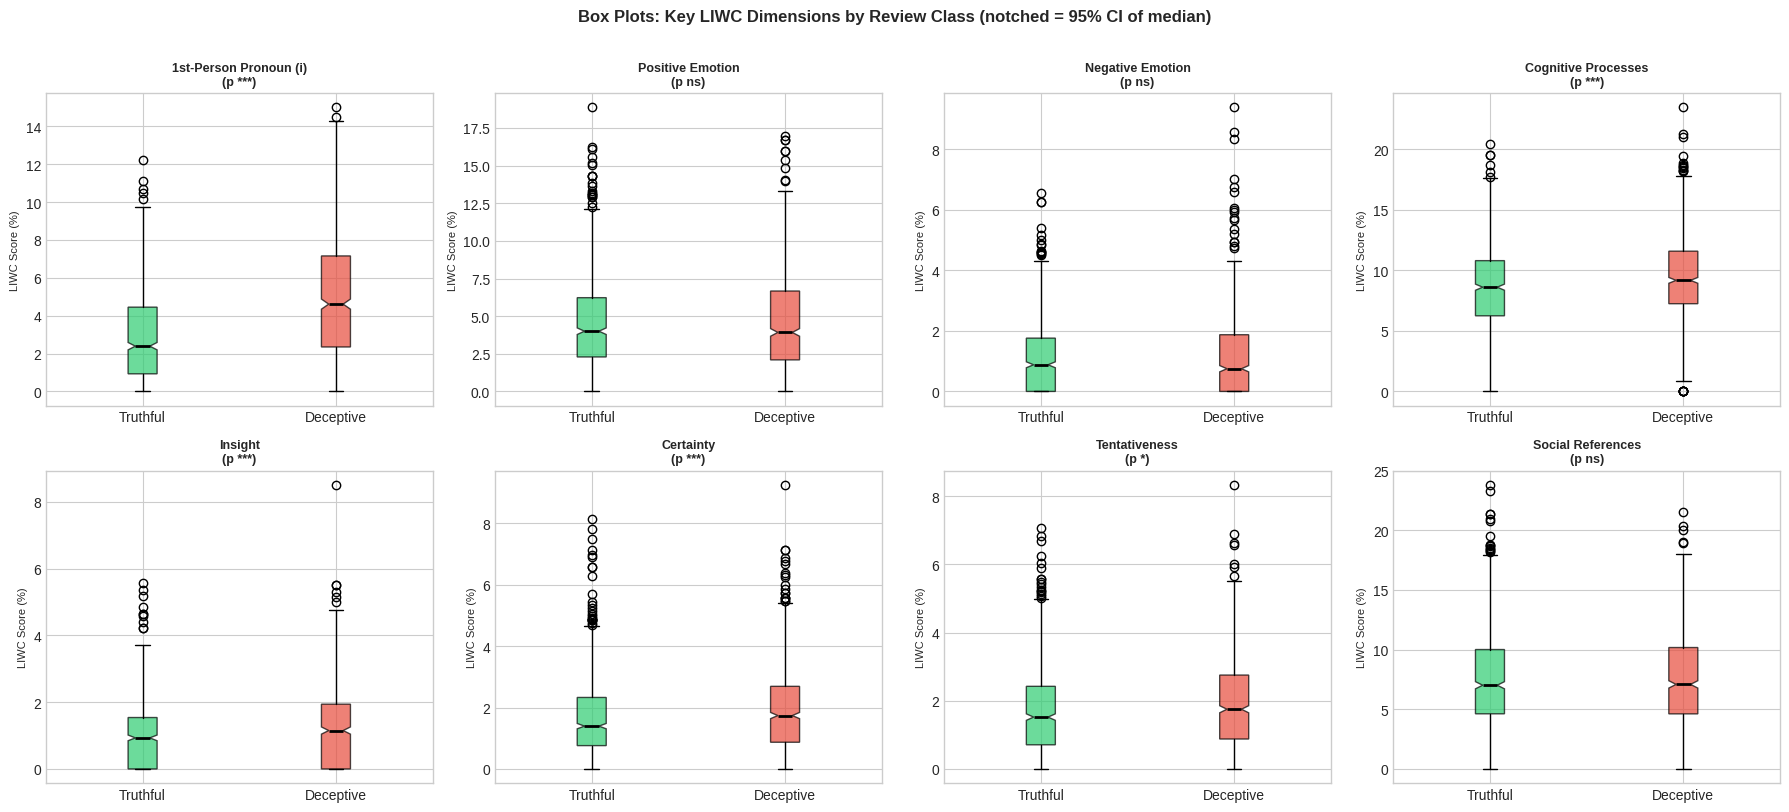

Figure saved: fig_boxplots_key_features.png


In [ ]:
BOX_FEATS = ['i', 'posemo', 'negemo', 'cogproc', 'insight', 'certain', 'tentat', 'social']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, feat in enumerate(BOX_FEATS):
    data_box = [
        df[df[TARGET]==0][feat].dropna().values,
        df[df[TARGET]==1][feat].dropna().values
    ]
    bp = axes[idx].boxplot(data_box, labels=['Truthful', 'Deceptive'],
                           patch_artist=True, notch=True,
                           medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    # t-test annotation
    t, p = ttest_ind(data_box[0], data_box[1])
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    axes[idx].set_title(f'{FEATURE_LABELS.get(feat,feat)}\n(p {sig})', fontsize=9, fontweight='bold')
    axes[idx].set_ylabel('LIWC Score (%)', fontsize=8)

plt.suptitle('Box Plots: Key LIWC Dimensions by Review Class (notched = 95% CI of median)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots_key_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_boxplots_key_features.png')

---
## 4. Data Preprocessing Pipeline
### 4.1 Feature Selection & Missing Values

In [ ]:
# ── Working on AllReviews (1600 records) ──────────────────────────────────────
X = df[FEAT_COLS].copy()
y = df[TARGET].copy()

# Check missing values
missing = X.isnull().sum()
print(f'Features with missing values: {(missing > 0).sum()}')
if (missing > 0).any():
    print(missing[missing > 0])
else:
    print('No missing values found.')

# Fill any missing values with column mean (§3.5.4)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEAT_COLS)

print(f'\nFeature matrix shape after imputation: {X_imputed.shape}')

Features with missing values: 0
No missing values found.

Feature matrix shape after imputation: (1600, 93)


### 4.2 Normalization (§3.5.3)
> MinMax scaling applied to structural features `WC` and `WPS` which have wide absolute ranges.

In [ ]:
# Identify structural features with large absolute ranges
STRUCT_FEATS = ['WC', 'WPS']

X_norm = X_imputed.copy()
mm_scaler = MinMaxScaler()
X_norm[STRUCT_FEATS] = mm_scaler.fit_transform(X_norm[STRUCT_FEATS])

print('MinMax normalization applied to structural features:')
print(X_norm[STRUCT_FEATS].describe().round(4))

print(f'\nFinal feature matrix: {X_norm.shape[0]} samples × {X_norm.shape[1]} features')
print(f'Class distribution  : {pd.Series(y).value_counts().to_dict()}')

MinMax normalization applied to structural features:
              WC        WPS
count  1600.0000  1600.0000
mean      0.1639     0.1216
std       0.1156     0.0787
min       0.0000     0.0000
25%       0.0843     0.0817
50%       0.1357     0.1108
75%       0.2082     0.1460
max       1.0000     1.0000

Final feature matrix: 1600 samples × 93 features
Class distribution  : {1: 800, 0: 800}


### 4.3 Train-Test Split (Stratified 80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f'Train set : {X_train.shape[0]} samples | Class dist: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test set  : {X_test.shape[0]} samples  | Class dist: {pd.Series(y_test).value_counts().to_dict()}')
print(f'\nStratification verified: equal proportions maintained in both splits.')

Train set : 1280 samples | Class dist: {0: 640, 1: 640}
Test set  : 320 samples  | Class dist: {1: 160, 0: 160}

Stratification verified: equal proportions maintained in both splits.


---
## 5. Machine Learning Model Training & Hyperparameter Tuning
### 5-Fold Stratified GridSearchCV (§3.6 & §3.8)

In [ ]:
from scipy.stats import loguniform, randint
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ── Reduce folds: 3 is enough for tuning (save 5→3 folds everywhere)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# ── Model 1: SVM ───────────────────────────────────────────────────────────────
# KEY CHANGE: LinearSVC is 10–100x faster than SVC(kernel='rbf') on most data.
# Wrap in CalibratedClassifierCV to get predict_proba() if you need it.
# ── Model 1: SVM ───────────────────────────────────────────────────────────────
print('Training SVM...')
svm_grid = RandomizedSearchCV(
    CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_SEED)),
    {'estimator__C': loguniform(0.01, 100)},  # ← was 'base_estimator__C'
    n_iter=10, cv=cv_strategy, scoring='f1', n_jobs=-1, random_state=RANDOM_SEED
)
svm_grid.fit(X_train, y_train)
print(f'  Best SVM params : {svm_grid.best_params_}')
print(f'  Best CV F1      : {svm_grid.best_score_:.4f}')
# ── Model 2: Random Forest ────────────────────────────────────────────────────
# KEY CHANGE: RandomizedSearchCV samples n_iter=10 combos instead of all 24.
# Also try fewer estimators first — 100 is usually enough for tuning.
print('\nTraining Random Forest...')
rf_params = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': randint(2, 10),   # continuous range, not 2 fixed values
}
rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED),
    rf_params, n_iter=10, cv=cv_strategy, scoring='f1',
    n_jobs=-1, random_state=RANDOM_SEED
)
rf_grid.fit(X_train, y_train)
print(f'  Best RF params  : {rf_grid.best_params_}')
print(f'  Best CV F1      : {rf_grid.best_score_:.4f}')

# ── Model 3: Logistic Regression ──────────────────────────────────────────────
# LR is already fast — keep GridSearch but reduce folds via cv_strategy above.
print('\nTraining Logistic Regression...')
lr_params = {
    'C'     : [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    lr_params, cv=cv_strategy, scoring='f1', n_jobs=-1
)
lr_grid.fit(X_train, y_train)
print(f'  Best LR params  : {lr_grid.best_params_}')
print(f'  Best CV F1      : {lr_grid.best_score_:.4f}')

print('\n✓ All models trained.')

Training SVM...
  Best SVM params : {'estimator__C': np.float64(0.017073967431528128)}
  Best CV F1      : 0.7723

Training Random Forest...
  Best RF params  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1      : 0.7612

Training Logistic Regression...
  Best LR params  : {'C': 0.1, 'solver': 'liblinear'}
  Best CV F1      : 0.7705

✓ All models trained.


---
## 6. Model Evaluation
### 6.1 Test-Set Performance Metrics

In [ ]:
best_models = {
    'SVM'                : svm_grid.best_estimator_,
    'Random Forest'      : rf_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_
}

eval_results = []

for name, model in best_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    eval_results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba)
    })

eval_df = pd.DataFrame(eval_results).set_index('Model')
print('Test-Set Performance Metrics:')
print('=' * 65)
print(eval_df.round(4).to_string())
print('=' * 65)

Test-Set Performance Metrics:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
SVM                    0.7844     0.7826  0.7875    0.7850   0.8649
Random Forest          0.7688     0.7756  0.7562    0.7658   0.8540
Logistic Regression    0.7875     0.7840  0.7938    0.7888   0.8643


### 6.2 5-Fold Cross-Validation Performance (Mean ± Std)

In [ ]:
cv_results = []
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for name, model in best_models.items():
    cv_scores = cross_validate(model, X_norm, y, cv=cv_strategy,
                               scoring=scoring_metrics, n_jobs=-1)
    row = {'Model': name}
    for metric in scoring_metrics:
        scores = cv_scores[f'test_{metric}']
        row[f'{metric.capitalize()}_Mean'] = scores.mean()
        row[f'{metric.capitalize()}_Std']  = scores.std()
    cv_results.append(row)

cv_df = pd.DataFrame(cv_results).set_index('Model')

# Pretty display
print('5-Fold Stratified Cross-Validation Results:')
print('=' * 70)
for metric in scoring_metrics:
    mean_col = f'{metric.capitalize()}_Mean'
    std_col  = f'{metric.capitalize()}_Std'
    print(f'\n{metric.upper()}:')
    for model_name in cv_df.index:
        m = cv_df.loc[model_name, mean_col]
        s = cv_df.loc[model_name, std_col]
        print(f'  {model_name:22s}: {m:.4f} ± {s:.4f}')
print('=' * 70)

5-Fold Stratified Cross-Validation Results:

ACCURACY:
  SVM                   : 0.7738 ± 0.0160
  Random Forest         : 0.7688 ± 0.0335
  Logistic Regression   : 0.7725 ± 0.0137

PRECISION:
  SVM                   : 0.7619 ± 0.0208
  Random Forest         : 0.7622 ± 0.0411
  Logistic Regression   : 0.7652 ± 0.0206

RECALL:
  SVM                   : 0.7975 ± 0.0228
  Random Forest         : 0.7838 ± 0.0341
  Logistic Regression   : 0.7875 ± 0.0176

F1:
  SVM                   : 0.7790 ± 0.0155
  Random Forest         : 0.7724 ± 0.0319
  Logistic Regression   : 0.7759 ± 0.0122

ROC_AUC:
  SVM                   : 0.8510 ± 0.0178
  Random Forest         : 0.8473 ± 0.0370
  Logistic Regression   : 0.8507 ± 0.0175


### 6.3 Performance Comparison Bar Chart

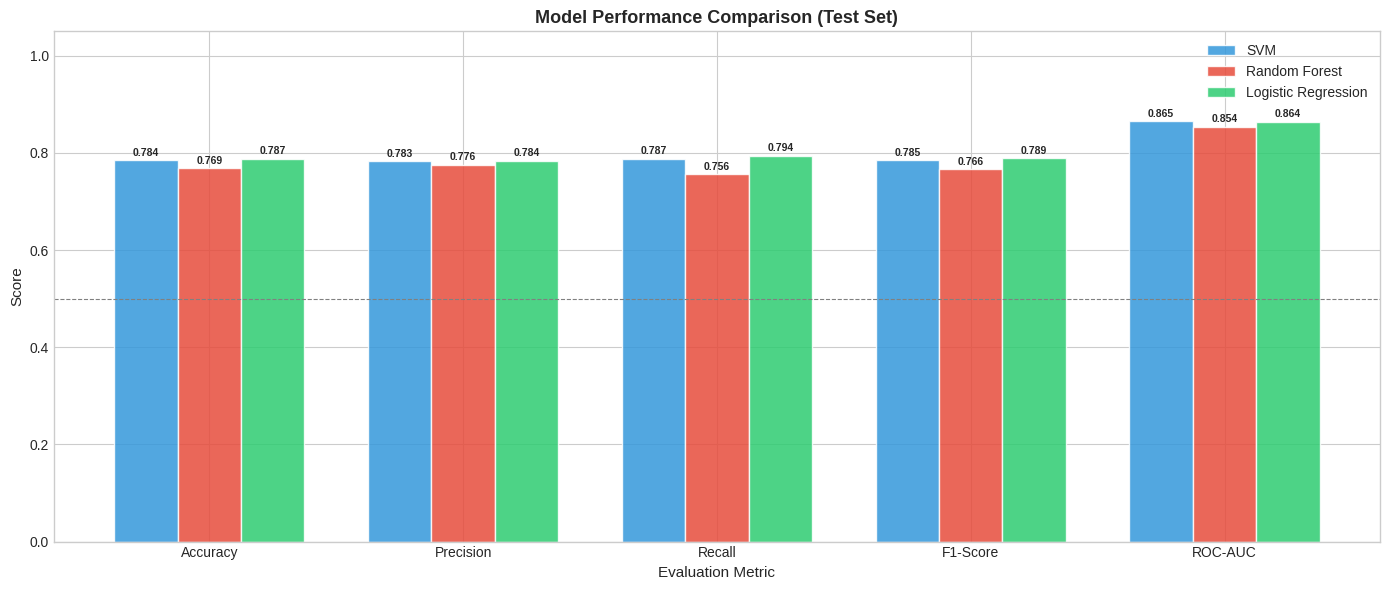

Figure saved: fig_model_comparison.png


In [ ]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models    = eval_df.index.tolist()
x         = np.arange(len(metrics))
width     = 0.25
colors    = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = eval_df.loc[model_name, metrics].values
    bars = ax.bar(x + i*width, vals, width, label=model_name,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Evaluation Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random Baseline')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_model_comparison.png')

### 6.4 ROC Curves

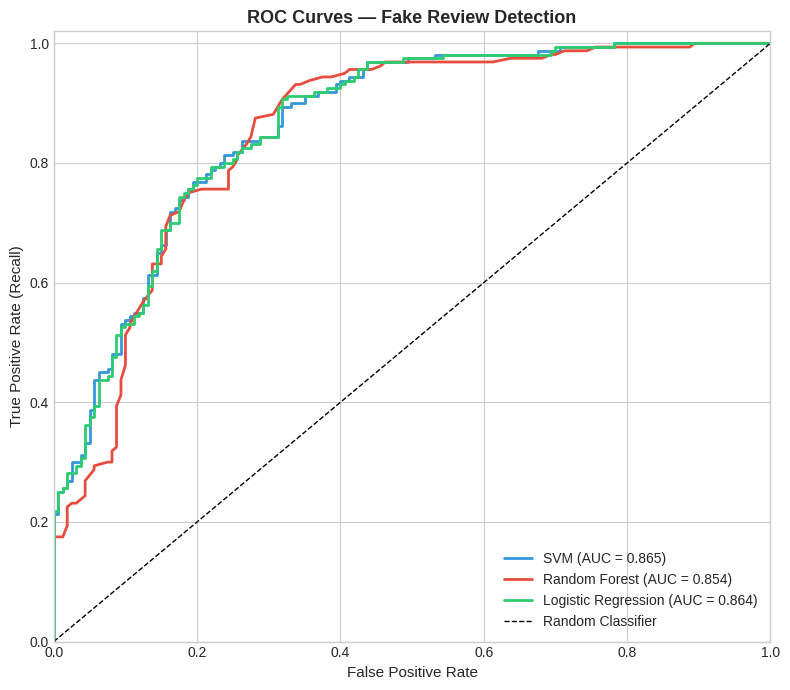

Figure saved: fig_roc_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, model), color in zip(best_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Fake Review Detection', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_roc_curves.png')

### 6.5 Confusion Matrices

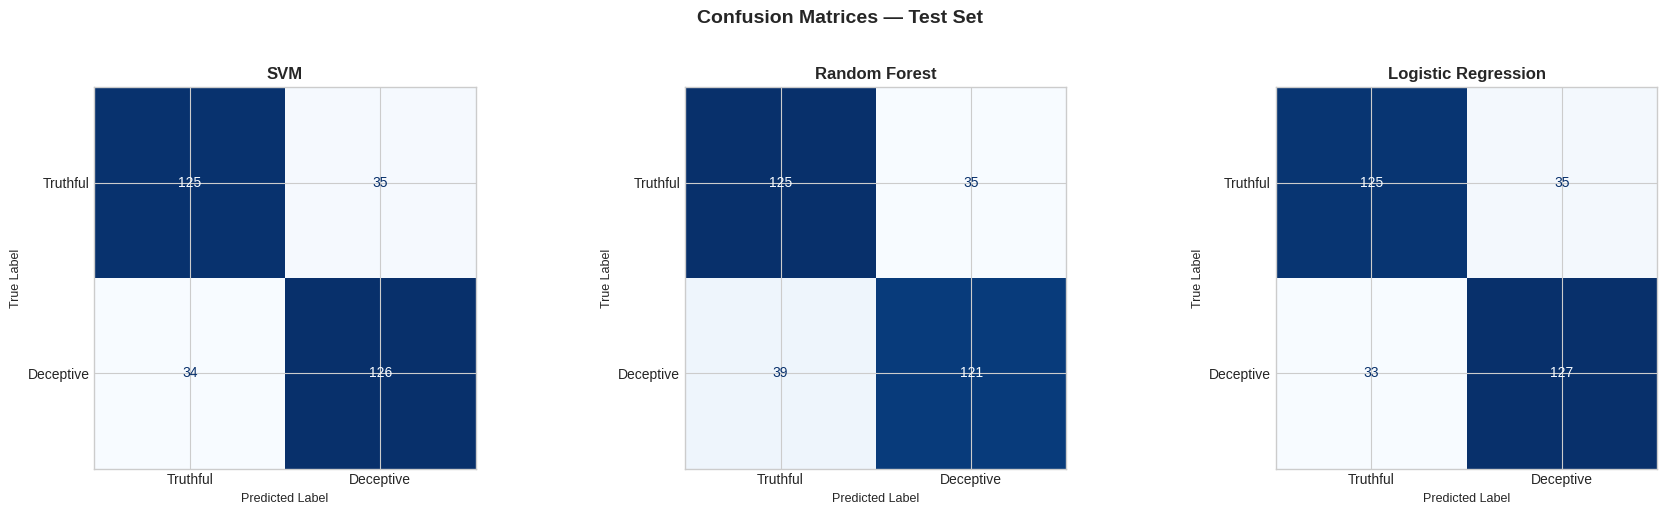

Figure saved: fig_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Truthful', 'Deceptive']

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_confusion_matrices.png')

### 6.6 Detailed Classification Reports

In [ ]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f'\n{'='*55}')
    print(f'  {name}')
    print('='*55)
    print(classification_report(y_test, y_pred, target_names=['Truthful','Deceptive']))


  SVM
              precision    recall  f1-score   support

    Truthful       0.79      0.78      0.78       160
   Deceptive       0.78      0.79      0.79       160

    accuracy                           0.78       320
   macro avg       0.78      0.78      0.78       320
weighted avg       0.78      0.78      0.78       320


  Random Forest
              precision    recall  f1-score   support

    Truthful       0.76      0.78      0.77       160
   Deceptive       0.78      0.76      0.77       160

    accuracy                           0.77       320
   macro avg       0.77      0.77      0.77       320
weighted avg       0.77      0.77      0.77       320


  Logistic Regression
              precision    recall  f1-score   support

    Truthful       0.79      0.78      0.79       160
   Deceptive       0.78      0.79      0.79       160

    accuracy                           0.79       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.79    

---
## 7. Feature Importance Analysis
### 7.1 Random Forest Gini Importance (Top 20)

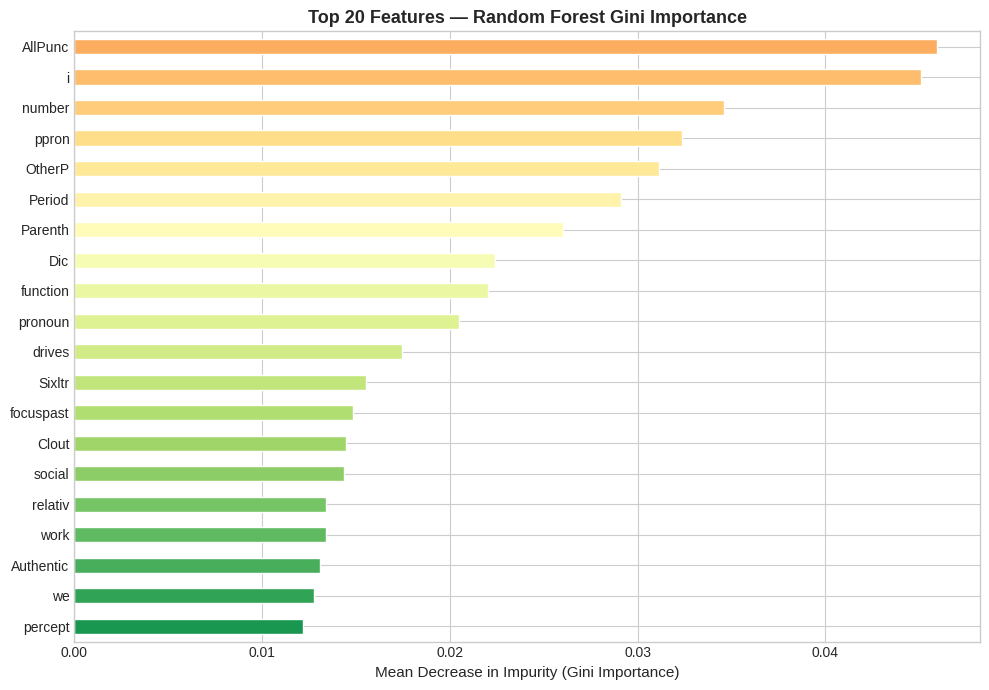

Figure saved: fig_gini_importance.png

Top 20 Gini Important Features:
AllPunc      0.04595
i            0.04509
number       0.03462
ppron        0.03239
OtherP       0.03116
Period       0.02913
Parenth      0.02605
Dic          0.02243
function     0.02206
pronoun      0.02048
drives       0.01743
Sixltr       0.01554
focuspast    0.01486
Clout        0.01446
social       0.01436
relativ      0.01343
work         0.01342
Authentic    0.01310
we           0.01275
percept      0.01219


In [ ]:
rf_best = rf_grid.best_estimator_
gini_importance = pd.Series(rf_best.feature_importances_, index=FEAT_COLS)
top20_gini = gini_importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_gini = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20))[::-1]
top20_gini.sort_values().plot(kind='barh', ax=ax, color=colors_gini, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontsize=11)
ax.set_title('Top 20 Features — Random Forest Gini Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_gini_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_gini_importance.png')
print('\nTop 20 Gini Important Features:')
print(top20_gini.round(5).to_string())

### 7.2 Logistic Regression Coefficients

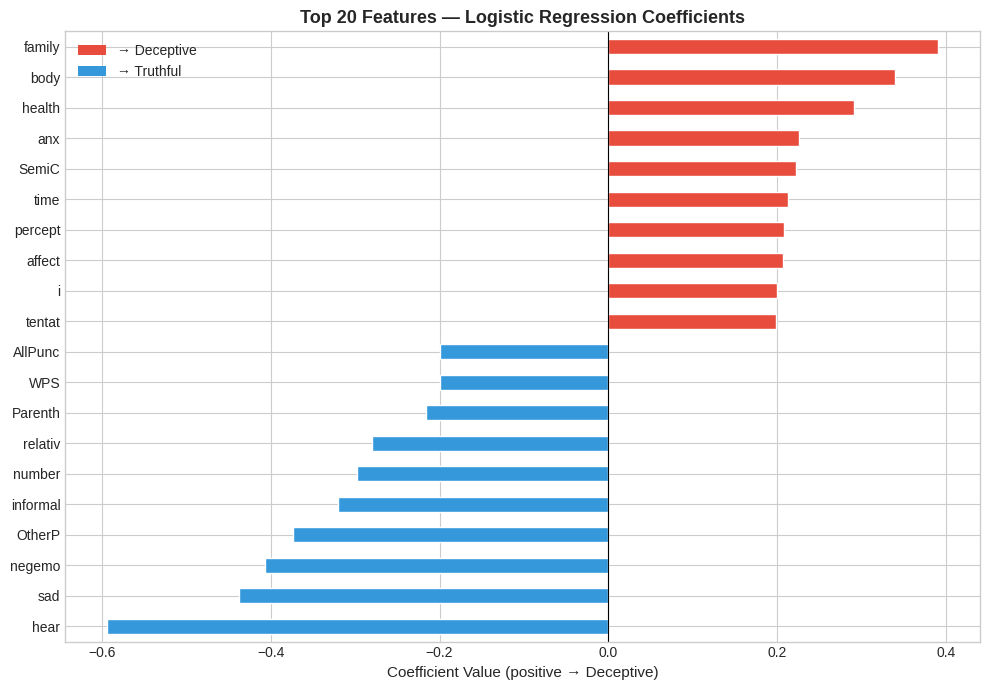

Figure saved: fig_lr_coefficients.png


In [ ]:
lr_best  = lr_grid.best_estimator_
lr_coefs = pd.Series(lr_best.coef_[0], index=FEAT_COLS)
top20_lr = lr_coefs.abs().nlargest(20)
top20_lr_signed = lr_coefs[top20_lr.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_lr = ['#e74c3c' if v > 0 else '#3498db' for v in top20_lr_signed]
top20_lr_signed.plot(kind='barh', ax=ax, color=colors_lr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value (positive → Deceptive)', fontsize=11)
ax.set_title('Top 20 Features — Logistic Regression Coefficients', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_lr = [Patch(facecolor='#e74c3c', label='→ Deceptive'),
             Patch(facecolor='#3498db', label='→ Truthful')]
ax.legend(handles=legend_lr)
plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_lr_coefficients.png')

---
## 8. SHAP Explainability Analysis (§3.9)
### 8.1 Compute SHAP Values for Random Forest

In [ ]:
print('Computing SHAP values for Random Forest (this may take 1-2 minutes)...')

# Use the test set for SHAP analysis
explainer   = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values[1] = contribution toward class 1 (Deceptive)
if isinstance(shap_values, list):
    shap_deceptive = shap_values[1]
else:
    shap_deceptive = shap_values

print(f'SHAP values shape: {shap_deceptive.shape}')
print('SHAP computation complete.')

Computing SHAP values for Random Forest (this may take 1-2 minutes)...
SHAP values shape: (320, 93, 2)
SHAP computation complete.


### 8.2 SHAP Summary Bar Plot (Global Feature Importance)

<Figure size 1000x800 with 0 Axes>

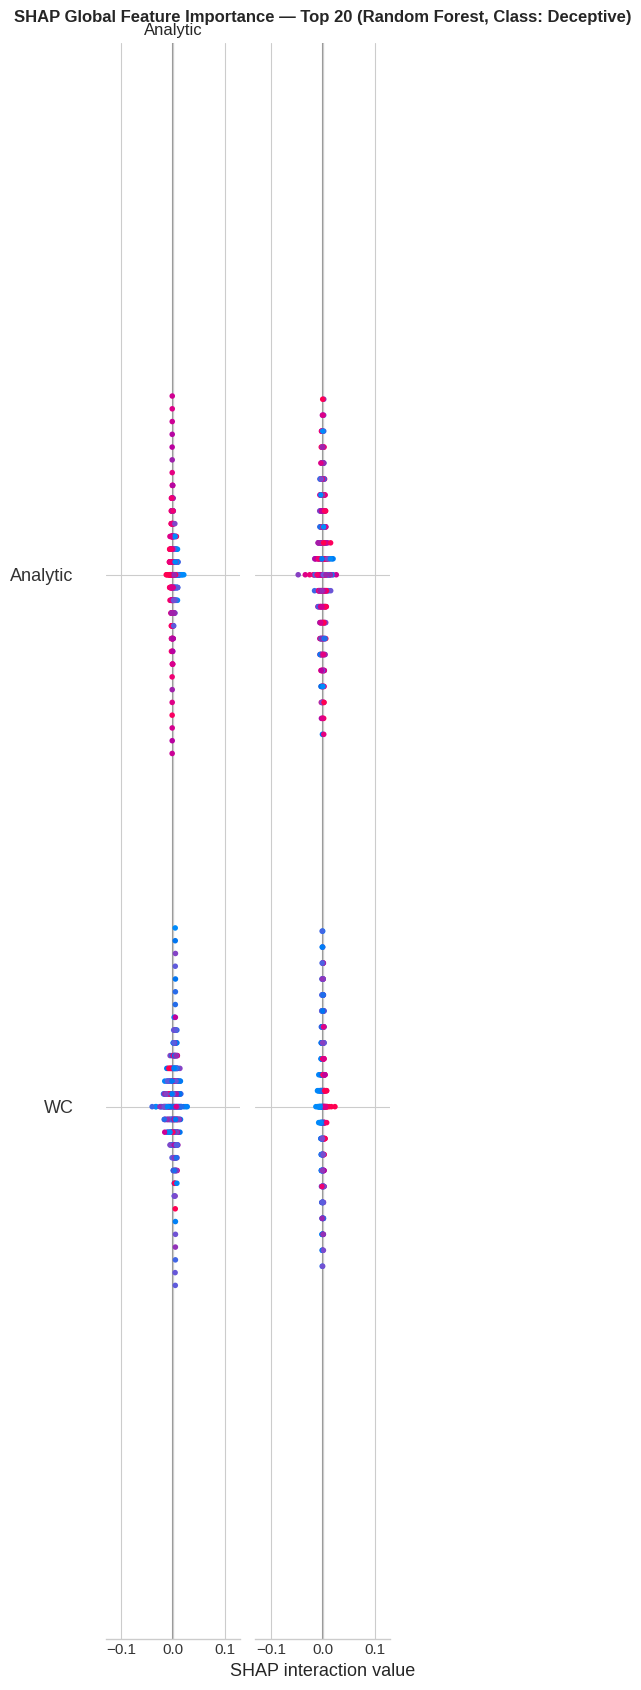

Figure saved: fig_shap_bar.png


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_deceptive, X_test,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Global Feature Importance — Top 20 (Random Forest, Class: Deceptive)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_shap_bar.png')

### 8.3 SHAP Beeswarm Plot (Impact Direction and Magnitude)

<Figure size 1000x800 with 0 Axes>

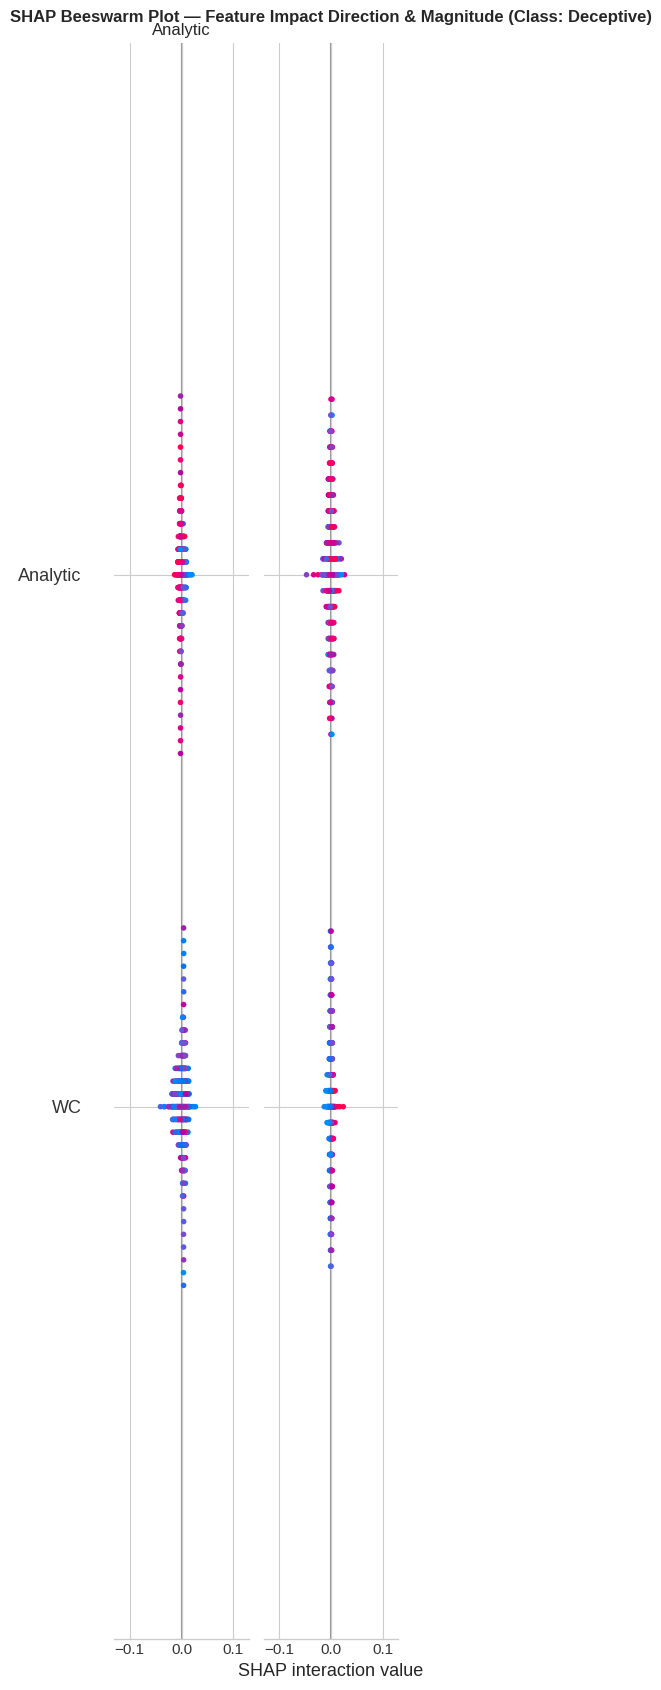

Figure saved: fig_shap_beeswarm.png


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_deceptive, X_test,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact Direction & Magnitude (Class: Deceptive)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_shap_beeswarm.png')

### 8.4 SHAP vs Gini Importance Rank Comparison (§3.9)

Top 20 Features: SHAP vs Gini Rank Comparison
           SHAP_Rank  Gini_Rank  Rank_Diff  SHAP_Value  Gini_Importance
AllPunc            1          1          0     0.04113          0.04595
i                  2          2          0     0.03532          0.04509
number             3          3          0     0.03415          0.03462
OtherP             4          5          1     0.03090          0.03116
ppron              5          4          1     0.03033          0.03239
Parenth            6          7          1     0.02745          0.02605
Period             7          6          1     0.02427          0.02913
Dic                8          8          0     0.01701          0.02243
function           9          9          0     0.01503          0.02206
pronoun           10         10          0     0.01461          0.02048
we                11         19          8     0.01304          0.01275
drives            12         11          1     0.01252          0.01743
Sixltr            

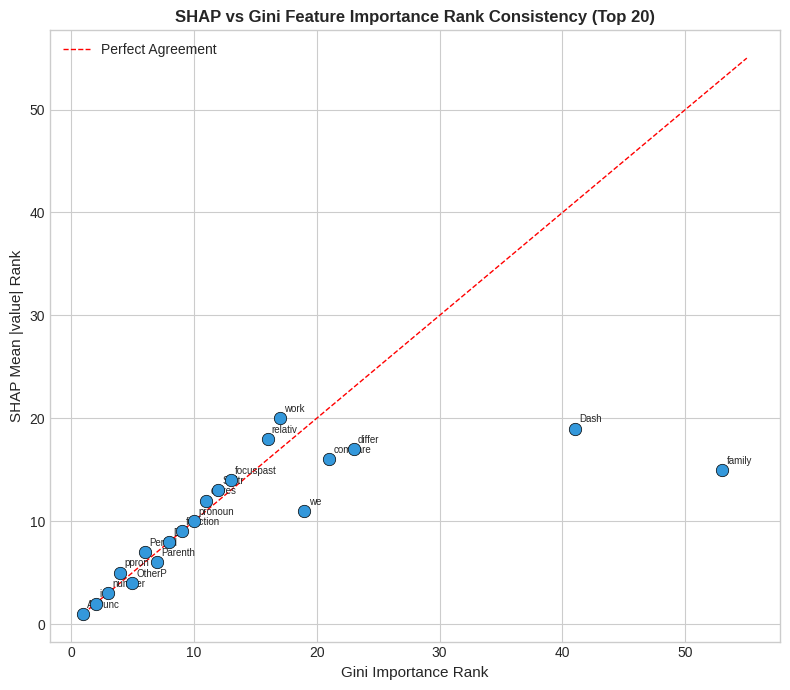


Figure saved: fig_shap_vs_gini_rank.png


In [ ]:
import shap

# SHAP mean absolute values
# Select the SHAP values for the 'Deceptive' class (class 1) from the 3D array
shap_mean_abs = pd.Series(
    np.abs(shap_deceptive[:, :, 1]).mean(axis=0),
    index=FEAT_COLS
)

# Build rank comparison DataFrame
shap_rank  = shap_mean_abs.rank(ascending=False).astype(int)
gini_rank  = gini_importance.rank(ascending=False).astype(int)

rank_df = pd.DataFrame({
    'SHAP_Rank'       : shap_rank,
    'Gini_Rank'       : gini_rank,
    'SHAP_Value'      : shap_mean_abs,
    'Gini_Importance' : gini_importance
}).sort_values('SHAP_Rank').head(20)
rank_df['Rank_Diff'] = abs(rank_df['SHAP_Rank'] - rank_df['Gini_Rank'])

print('Top 20 Features: SHAP vs Gini Rank Comparison')
print('='*65)
print(rank_df[['SHAP_Rank','Gini_Rank','Rank_Diff','SHAP_Value','Gini_Importance']].round(5).to_string())

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 7))
top20_feats = rank_df.index.tolist()
ax.scatter(rank_df['Gini_Rank'], rank_df['SHAP_Rank'],
           s=80, color='#3498db', edgecolors='black', linewidth=0.5, zorder=5)
for feat in top20_feats:
    ax.annotate(feat, (rank_df.loc[feat,'Gini_Rank'], rank_df.loc[feat,'SHAP_Rank']),
                fontsize=7, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
# Perfect agreement line
lim = max(rank_df['Gini_Rank'].max(), rank_df['SHAP_Rank'].max()) + 2
ax.plot([1, lim], [1, lim], 'r--', linewidth=1, label='Perfect Agreement')
ax.set_xlabel('Gini Importance Rank', fontsize=11)
ax.set_ylabel('SHAP Mean |value| Rank', fontsize=11)
ax.set_title('SHAP vs Gini Feature Importance Rank Consistency (Top 20)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_shap_vs_gini_rank.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nFigure saved: fig_shap_vs_gini_rank.png')

### 8.5 SHAP Dependence Plots (Top 4 Features)

Top 4 SHAP features: ['AllPunc', 'i', 'number', 'OtherP']


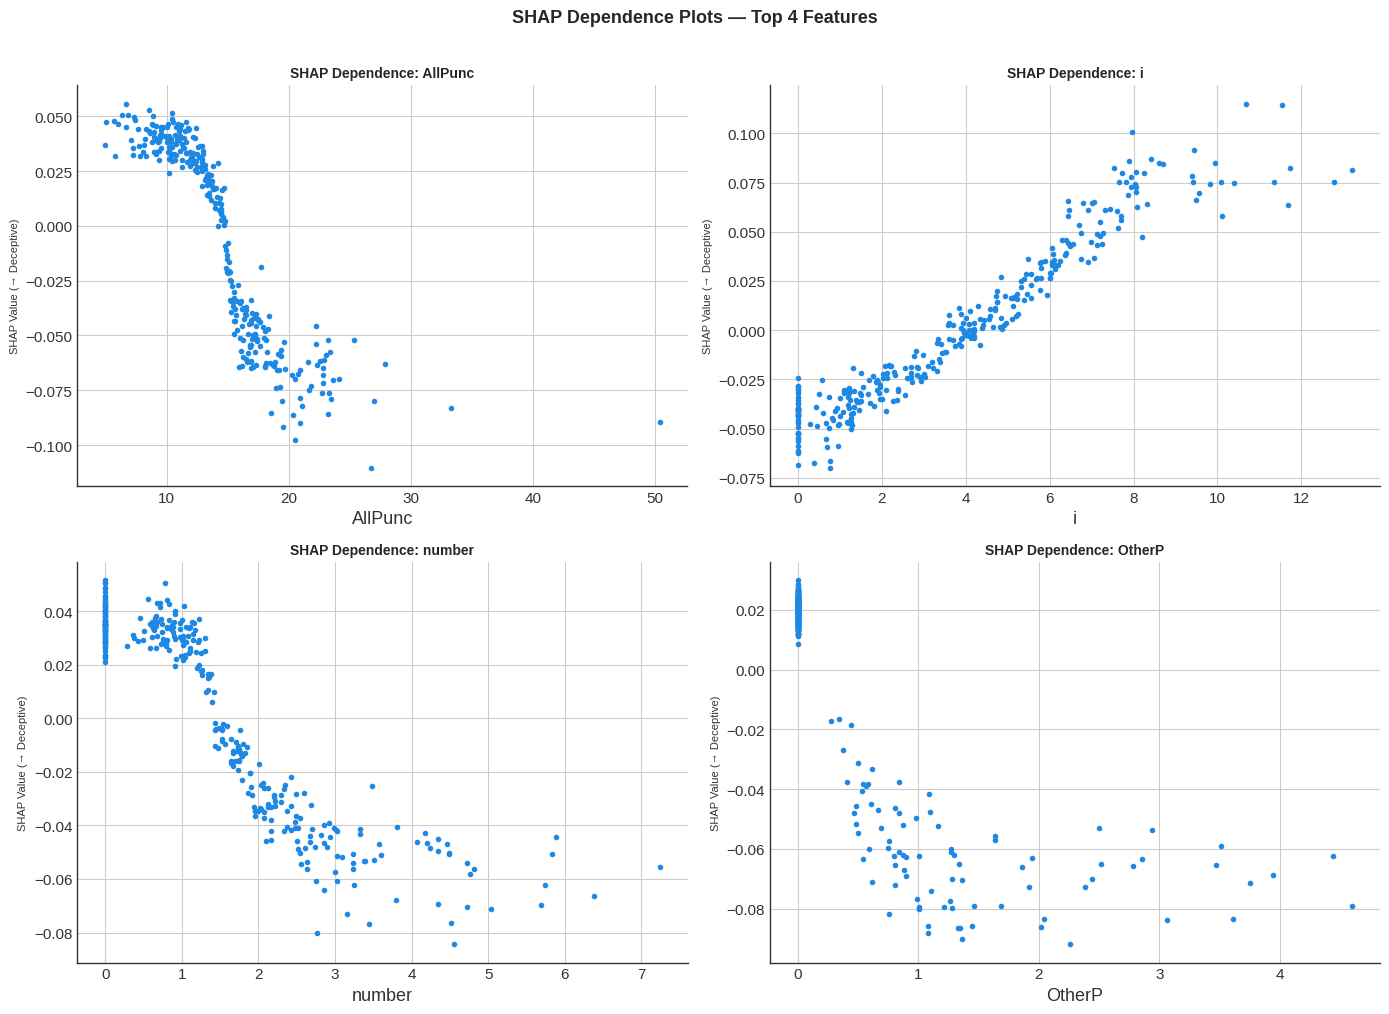

Figure saved: fig_shap_dependence.png


In [ ]:
top4_shap = shap_mean_abs.nlargest(4).index.tolist()
print(f'Top 4 SHAP features: {top4_shap}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(top4_shap):
    feat_idx = list(X_test.columns).index(feat)
    shap.dependence_plot(
        feat_idx, shap_deceptive[:, :, 1], X_test,  # Corrected: select SHAP values for class 1
        ax=axes[idx], show=False,
        interaction_index=None
    )
    axes[idx].set_title(f'SHAP Dependence: {feat}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('SHAP Value (→ Deceptive)', fontsize=8)

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_shap_dependence.png')

---
## 9. Cross-Validation Learning Curves

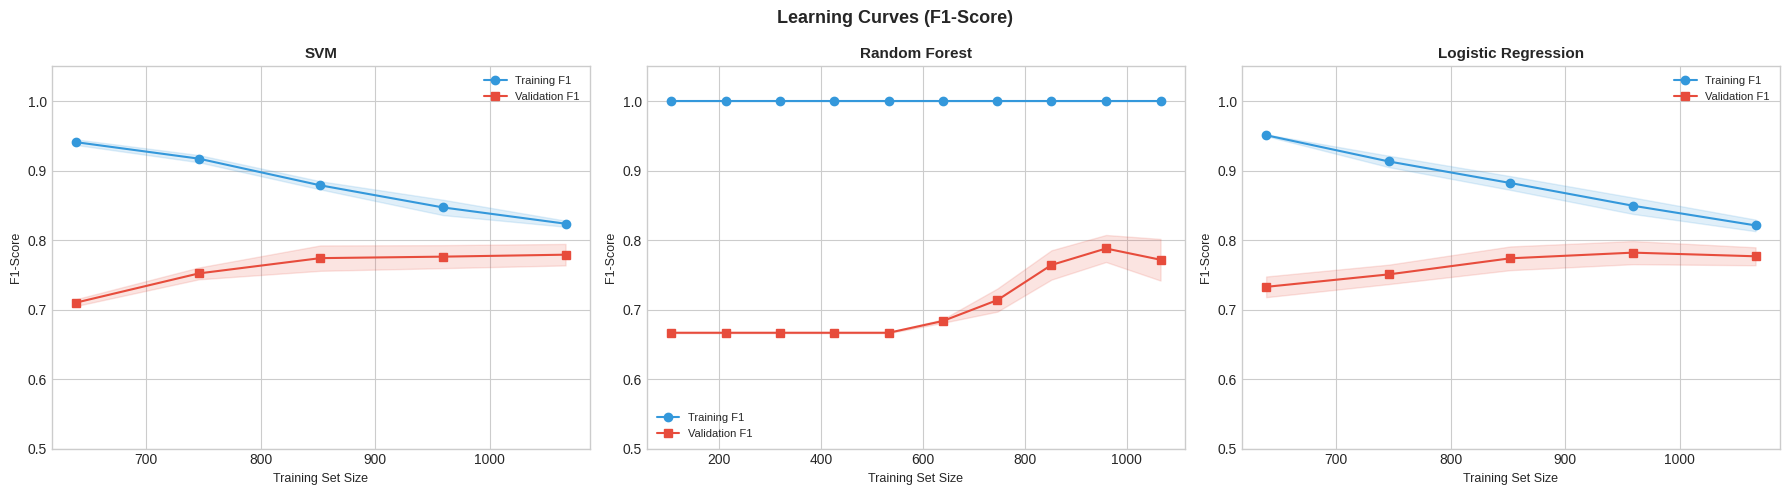

Figure saved: fig_learning_curves.png


In [ ]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    train_sz, train_sc, val_sc = learning_curve(
        model, X_norm, y,
        cv=cv_strategy, scoring='f1',
        train_sizes=train_sizes, n_jobs=-1
    )
    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='#3498db', label='Training F1')
    ax.fill_between(train_sz, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#3498db')
    ax.plot(train_sz, val_mean, 's-', color='#e74c3c', label='Validation F1')
    ax.fill_between(train_sz, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#e74c3c')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Set Size', fontsize=9)
    ax.set_ylabel('F1-Score', fontsize=9)
    ax.set_ylim([0.5, 1.05])
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves (F1-Score)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_learning_curves.png')

---
## 10. Final Summary Table

In [ ]:
print('\n' + '='*75)
print('  CHAPTER 4 — FINAL RESULTS SUMMARY')
print('='*75)
print('\n[1] TEST-SET PERFORMANCE (80/20 stratified split):')
print(eval_df.round(4).to_string())

print('\n[2] 5-FOLD CROSS-VALIDATION (mean ± std):')
cv_summary = []
for name in best_models:
    row = {'Model': name}
    for metric in scoring_metrics:
        m = cv_df.loc[name, f'{metric.capitalize()}_Mean']
        s = cv_df.loc[name, f'{metric.capitalize()}_Std']
        row[metric.upper()] = f'{m:.4f} ± {s:.4f}'
    cv_summary.append(row)
print(pd.DataFrame(cv_summary).set_index('Model').to_string())

print('\n[3] TOP 10 SHAP FEATURES (mean |SHAP value|):')
top10_shap = shap_mean_abs.nlargest(10)
for rank, (feat, val) in enumerate(top10_shap.items(), 1):
    gini_val = gini_importance[feat]
    print(f'  {rank:2d}. {feat:15s} SHAP={val:.5f}  Gini={gini_val:.5f}')

print('\n[4] BEST MODEL:')
best_model_name = eval_df['F1-Score'].idxmax()
best_f1 = eval_df.loc[best_model_name, 'F1-Score']
best_auc = eval_df.loc[best_model_name, 'ROC-AUC']
print(f'  {best_model_name} — F1={best_f1:.4f}, ROC-AUC={best_auc:.4f}')

print('\n' + '='*75)


  CHAPTER 4 — FINAL RESULTS SUMMARY

[1] TEST-SET PERFORMANCE (80/20 stratified split):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
SVM                    0.7844     0.7826  0.7875    0.7850   0.8649
Random Forest          0.7688     0.7756  0.7562    0.7658   0.8540
Logistic Regression    0.7875     0.7840  0.7938    0.7888   0.8643

[2] 5-FOLD CROSS-VALIDATION (mean ± std):
                            ACCURACY        PRECISION           RECALL               F1          ROC_AUC
Model                                                                                                   
SVM                  0.7738 ± 0.0160  0.7619 ± 0.0208  0.7975 ± 0.0228  0.7790 ± 0.0155  0.8510 ± 0.0178
Random Forest        0.7688 ± 0.0335  0.7622 ± 0.0411  0.7838 ± 0.0341  0.7724 ± 0.0319  0.8473 ± 0.0370
Logistic Regression  0.7725 ± 0.0137  0.7652 ± 0.0206  0.7875 ± 0.0176  0.7759 ± 0.0122  0.8507 ± 0.0175

[3